# Practical: CNNs and Data Augmentation
## Objective: In this practical session, we will:

* Visualizing Augmentation: See exactly how we mechanically alter images to create "new" data.
* Build a CNN: Write a Convolutional Neural Network from scratch for CIFAR-10.
* The Experiment: Train two identical models—one with standard data, one with Data Augmentation—and prove that augmentation reduces overfitting.

Dataset: CIFAR-10 (10 classes: plane, car, bird, cat, deer, dog, frog, horse, ship, truck).

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import time

# Check for device (falls back to CPU if no GPU, which is fine for this size)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Part 0: Classic Computer Vision (The "Why" of CNNs)
Before Deep Learning, computer vision engineers had to manually design filters (kernels) to extract features like edges, corners, and textures.

A CNN simply learns these kernels instead of us having to guess them. Let's look at how a Kernel works mechanically using OpenCV.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Download/Load the image (if not already loaded)
# We use grayscale for classic CV because color adds unnecessary complexity for edges
img_bgr = cv2.imread("dog.jpg")
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

def show_cv2(img, title="Image"):
    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

show_cv2(img_gray, "Original Grayscale")

### 1. Blurring (Low-pass Filters)
Blurring averages neighboring pixels. It is crucial for removing noise before detecting edges.

Gaussian Blur: Uses a weighted average (pixels closer to center matter more).

In [ ]:
# 5x5 Gaussian Kernel
# The larger the kernel size (ksize), the stronger the blur
img_blur = cv2.GaussianBlur(img_gray, ksize=(15, 15), sigmaX=0)

# Display side-by-side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img_gray, cmap='gray'); ax[0].set_title("Original")
ax[1].imshow(img_blur, cmap='gray'); ax[1].set_title("Gaussian Blur (15x15 Kernel)")
for a in ax: a.axis('off')
plt.show()

### 2. Manual Kernels: Sharpening
Instead of using a built-in function, let's define a kernel matrix manually and apply it using `cv2.filter2D`. This is exactly what a Convolutional Layer does during the forward pass!

A Sharpening Kernel typically creates a difference between the center pixel and its neighbors.

In [ ]:
# Define the Sharpening Kernel manually
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Apply the kernel (Convolution)
# ddepth=-1 means the output image will have the same depth (e.g., 8-bit) as the source
img_sharp = cv2.filter2D(img_gray, ddepth=-1, kernel=sharpen_kernel)

show_cv2(img_sharp, "Sharpening Kernel Applied")

### 3. Edge Detection (Sobel & Canny)
Edge detection is about finding where pixel intensity changes rapidly (gradients).

Sobel: Finds vertical or horizontal gradients.

Canny: A multi-stage algorithm that finds "thin" strong edges.

In [ ]:
# Sobel X (Vertical Edges) - notice the vertical lines of the dog's leg/door
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)

# Sobel Y (Horizontal Edges) - notice the nose and eyes
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

# Canny Edge Detection (The Gold Standard)
# Thresholds determine how "strong" an edge must be to be kept
edges = cv2.Canny(img_gray, threshold1=100, threshold2=200)

# Visualize
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(np.abs(sobelx), cmap='gray'); ax[0].set_title("Sobel X (Vertical Gradients)")
ax[1].imshow(np.abs(sobely), cmap='gray'); ax[1].set_title("Sobel Y (Horizontal Gradients)")
ax[2].imshow(edges, cmap='gray'); ax[2].set_title("Canny Edge Detector")
for a in ax: a.axis('off')
plt.show()

### 4. Corner Detection (Harris)
Corners are regions with high variation in intensity in all directions. The Harris Corner Detector is a classic mathematical approach to finding these points.

Note: In CNNs, early layers often learn to detect edges (like Sobel), and deeper layers combine them to find corners and shapes.

In [ ]:
# Harris works best on float32 grayscale
gray_float = np.float32(img_gray)

# dst is the "Corner Response" map
# blockSize=2, ksize=3, k=0.04 are standard params
dst = cv2.cornerHarris(gray_float, blockSize=2, ksize=3, k=0.04)

# Dilate result to make the corners bigger/visible for plotting
dst = cv2.dilate(dst, None)

# Threshold for an optimal value, it may vary depending on the image.
# We modify the ORIGINAL color image to draw red dots on corners
img_corners = img_bgr.copy()
img_corners[dst > 0.01 * dst.max()] = [0, 0, 255] # Red dots

# Convert BGR to RGB for matplotlib
img_corners = cv2.cvtColor(img_corners, cv2.COLOR_BGR2RGB)

show_cv2(img_corners, "Harris Corners (Red Dots)")

## Part 1: Visualizing Data Augmentation
Before we train, let's see what the network "sees". We will define a transform pipeline with RandomHorizontalFlip, RandomRotation, and ColorJitter.

Run this cell multiple times to see different random variations of the same images.

100%|████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:59<00:00, 2.86MB/s]


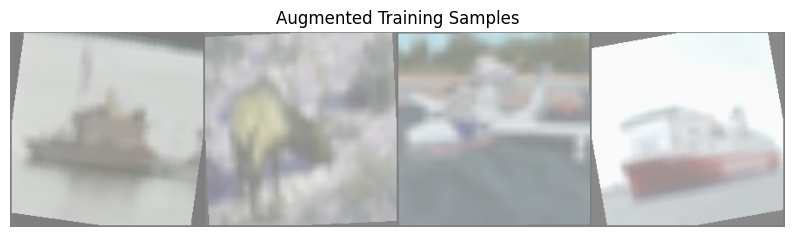

In [ ]:
# Helper function to show images
def imshow(img, title=None):
    img = img / 2 + 0.5  # unnormalize for display
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title:
        plt.title(title)
    plt.axis('off')

# Define a temporary transform just for visualization
# We use strong augmentation here to make the effects obvious
viz_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize bigger just to see it clearly
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15), # Rotate +/- 15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
])

# Load a small batch just for visualization
vizset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=viz_transform)
vizloader = torch.utils.data.DataLoader(vizset, batch_size=4, shuffle=True)

# Get some random training images
dataiter = iter(vizloader)
images, labels = next(dataiter)

# Show images
plt.figure(figsize=(10, 5))
imshow(torchvision.utils.make_grid(images), title="Augmented Training Samples")
plt.show()

## Part 2: Preparing Data Loaders
We will create two different training sets to compare performance:

* Baseline (No Aug): Just converts to Tensor and Normalizes.
* Augmented: Adds RandomCrop, Flip, and Rotation.

Note: We NEVER augment the Test set.

In [ ]:
# Standard CIFAR-10 normalization stats
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))

# 1. Baseline Transforms (No Augmentation)
transform_baseline = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# 2. Augmented Transforms (Strong Regularization)
transform_augmented = transforms.Compose([
    transforms.RandomCrop(32, padding=4),       # Padding preserves size after crop
    transforms.RandomHorizontalFlip(),          # 50% chance to flip
    transforms.RandomRotation(10),              # Slight rotation
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# Test Transforms (Validation only)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

# If using CPU, batch_size=64 might feel slightly snappier than 128
batch_size = 64

# Baseline Train Loader
trainset_base = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_baseline)
trainloader_base = torch.utils.data.DataLoader(trainset_base, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Augmented Train Loader
trainset_aug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_augmented)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Test Loader
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=0)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

## Part 3: Building the CNN
We will define a standard CNN with:

* Convolutional Blocks (Conv -> BatchNorm -> ReLU -> MaxPool)
* Dropout (Regularization)
* Fully Connected Head

Use
```python
nn.Conv2d(input_layers, output_layers, kernel_size, padding)
nn.BatchNorm2d(num_layers)
nn.MaxPool2d(pool_size)
nn.Flatten()
nn.Linear(input_neurons, output_neurons)
```

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # TODO: define blocks

    def forward(self, x):
        # TODO: implement forward pass
        return x

# Verify model shape
model = SimpleCNN().to(device)
print(model)

SimpleCNN()


## Under the Hood: Backpropagation in CNNs

You already know that PyTorch builds a computational graph and uses the chain rule to pass gradients backward. But how does this actually work with the unique spatial operations in a CNN? Let's look at the two main components: **Pooling** and **Convolution**.

### 1. Max Pooling: The Gradient Router
Max pooling layers don't have learnable weights, but gradients still need to pass *through* them to reach the convolutional layers before them. Because `MaxPool` only selects the maximum value in a window, it acts like a switch or a router.

Mathematically, if an output $y = \max(x_1, x_2, x_3, x_4)$ and $x_4$ was the maximum, the derivative $\frac{\partial y}{\partial x_4} = 1$, and the derivatives for the others are $0$. During backpropagation, the gradient from the next layer is routed **only** to the pixel that "won" the max pooling. The other pixels get a gradient of 0 because changing them slightly wouldn't have affected the output.

### 2. Convolution: Shared Weights and Gradient Summation
In a standard dense layer, each weight connects one input to one output. In a convolution, a single weight in the kernel slides across the image, contributing to *many* different outputs. This is **weight sharing**.

How do we calculate the gradient for a shared weight? By the multivariable chain rule, we **sum** the gradients from all the output locations it influenced.
If a weight $w$ is used to compute outputs $y_1, y_2, y_3$, then its gradient with respect to the loss $L$ is:
$\frac{\partial L}{\partial w} = \sum_{i} \frac{\partial L}{\partial y_i} \frac{\partial y_i}{\partial w}$

Let's prove both of these concepts in code.

In [ ]:
import torch
import torch.nn as nn

# ---------------------------------------------------------
# 1. MAX POOLING: Gradient Routing
# ---------------------------------------------------------
print("--- 1. Max Pooling: Gradient Routing ---")
# A simple 2x2 input
x_pool = torch.tensor([[[[1.0, 2.0],
                         [3.0, 4.0]]]], requires_grad=True)

pool = nn.MaxPool2d(kernel_size=2)
out_pool = pool(x_pool)

print(f"Input:\n{x_pool.squeeze()}")
print(f"Output (Max Value):\n{out_pool.squeeze()}")

# Simulate a gradient of 10.0 arriving from the deeper layers
out_pool.backward(torch.tensor([[[[10.0]]]]))

# Look at where the gradient goes!
print(f"Gradient at Input:\n{x_pool.grad.squeeze()}")
print("Notice how the gradient of 10.0 ONLY flows to the pixel that had the value 4.0.")
print("\n" + "="*40 + "\n")


# ---------------------------------------------------------
# 2. CONVOLUTION: Gradient Summation via Shared Weights
# ---------------------------------------------------------
print("--- 2. Convolution: Gradient Summation ---")
# A 3x3 input image of all 1s
x_conv = torch.ones(1, 1, 3, 3)

# A 2x2 convolutional kernel (4 weights total)
conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=2, bias=False)

# Initialize all weights to 0.5 for easy tracking
nn.init.constant_(conv.weight, 0.5)

out_conv = conv(x_conv) # This will produce a 2x2 output (4 pixels)

# Simulate a gradient of 1.0 arriving from the next layer for all 4 output pixels
out_conv.backward(torch.ones(1, 1, 2, 2))

print(f"Single Conv Weight Data:\n{conv.weight.data.squeeze()}")
print(f"PyTorch Calculated Gradient for the Weights:\n{conv.weight.grad.squeeze()}")
print("\nWhy is the gradient 4.0 for every weight?")
print("Because each weight slid over a 3x3 image to produce a 2x2 output, meaning it was used exactly 4 times.")
print("The chain rule sums the gradient (1.0) from all 4 locations: 1 + 1 + 1 + 1 = 4.0.")

## Part 4: Training Loop
We define a reusable function train_model so we can easily compare our experiments.

In [ ]:
def train_model(model, train_loader, test_loader, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # Evaluate on Test Set
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_acc = 100 * correct / total
        avg_loss = running_loss / len(train_loader)

        train_losses.append(avg_loss)
        test_accs.append(epoch_acc)

        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.2f}%")

    print(f"Training finished in {time.time() - start_time:.2f}s")
    return train_losses, test_accs

## Part 5: The Experiments
### Hypothesis:
* Without Augmentation: The model will learn very fast (low training loss) but might struggle to generalize (lower test acc).
* With Augmentation: The model will find the task "harder" (higher training loss) but will generalize better to the unseen test set.

Note: We are running for 5 epochs to save time. In a real scenario, you would train for 20-50 epochs.

In [ ]:
print("--- EXPERIMENT 1: Baseline (No Augmentation) ---")
model_base = SimpleCNN().to(device)
loss_base, acc_base = train_model(model_base, trainloader_base, testloader, epochs=5)

print("\n--- EXPERIMENT 2: With Data Augmentation ---")
model_aug = SimpleCNN().to(device)
loss_aug, acc_aug = train_model(model_aug, trainloader_aug, testloader, epochs=5)

## Part 6: Visualize Results
Let's plot the training curves.

* Loss: You might see the Augmentation loss is higher (it's harder to learn).
* Accuracy: You want to see the Augmentation accuracy ending higher or climbing more steadily.

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(loss_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(loss_aug, label='With Augmentation', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(acc_base, label='Baseline (No Aug)', linestyle='--')
plt.plot(acc_aug, label='With Augmentation', linewidth=2)
plt.title('Test Accuracy')
plt.xlabel('Epochs')
plt.legend()

plt.show()

## Part 7: Error Analysis - Finding the Model's Blind Spots

We just saw the overall accuracy of our models, but a single number doesn't tell the whole story. A crucial skill in Computer Vision is **Error Analysis**.

Your task for the remainder of the class is to investigate *what* the augmented model is getting wrong. You will write code to run the test set through our trained model, but instead of just calculating accuracy, you need to find the **most confidently incorrect predictions**.

**Your Goals:**
1. Loop through the test dataloader.
2. Get the model's predicted probabilities (use `torch.softmax`).
3. Identify images where the `predicted_class != true_class`.
4. Sort these mistakes by the probability of the *wrong* class (finding where the model was wrong, but highly confident).
5. Plot the top 5 worst mistakes, showing the image, the predicted class, its confidence, and the actual true class.

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# TODO: Complete this cell to find and visualize the top 5 confidently incorrect predictions.
# Assume 'augmented_model' is our trained model and 'test_loader' is available.

augmented_model.eval() # Ensure model is in evaluation mode
mistakes = [] # Store tuples of (confidence, image, predicted_label, true_label)

with torch.no_grad():
    for images, labels in test_loader:
        # Move to device if using GPU
        # images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        # outputs = ...

        # 2. Get probabilities and predictions
        # probs = ...
        # preds = ...

        # 3. Find where preds != labels and store the relevant data
        # HINT: Loop through the batch and append to the 'mistakes' list
        pass

# 4. Sort the mistakes list by confidence (highest confidence first)
# mistakes.sort(...)

# 5. Plot the top 5 mistakes
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
# for i in range(5):
#     conf, img, pred, true = mistakes[i]
#     # Code to unnormalize and imshow the image here...
#     axes[i].set_title(f"Pred: {classes[pred]} ({conf:.2f})\nTrue: {classes[true]}")
#     axes[i].axis('off')

plt.tight_layout()
plt.show()